# Week 2 — Value & Momentum Factor Analysis

**Goal.** Build and evaluate two classic equity factors on a 100-stock S&P 500 universe
(2016-08 → 2026-08, monthly rebalancing):

- **Value** — B/M (book-to-market) and E/P (trailing-twelve-month earnings-to-price)
- **Momentum** — 12-1 price momentum (skipping the most recent month)

**Method.** At each month-end rebalance date, stocks are ranked cross-sectionally by signal
and sorted into quintiles (Q1 = lowest signal, Q5 = highest). Portfolios are held
equal-weighted for one month and evaluated on the next-period return.

**Data integrity.** All fundamentals are **point-in-time**: a quarterly figure is only used
at rebalance date *t* if its SEC **filing date ≤ t**. No look-ahead anywhere in the pipeline.

*Deliverables: `src/factor_utils.py` (construction + backtest library), this notebook,
`weekly_memo.md` (factor memo). Raw data pipeline: Yahoo Finance (prices) + SEC EDGAR
companyfacts API (fundamentals); see memo appendix for the full script chain.*

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- locate repo root (folder containing src/) ---
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.factor_utils import (FACTOR_LABELS, backtest_factor, ic_stats,
                              load_rf_monthly, quintile_stats,
                              yearly_ls_returns)

# --- data locations (adjust if you move the data into the repo) ---
DATA_DIR = Path(r"C:\Users\dwt04\Desktop\北美求职\LENDO\dataset\week2")
PANEL_PATH = DATA_DIR / "factors" / "factor_panel_monthly.csv"
RF_PATH = DATA_DIR / "week2_risk_free_irx_10y.csv"

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Panel: {PANEL_PATH}")

Project root: C:\Users\dwt04\Documents\kimi\workspace\Lendo-week2-complete
Panel: C:\Users\dwt04\Desktop\北美求职\LENDO\dataset\week2\factors\factor_panel_monthly.csv


## 1. Data & Point-in-Time Construction

| Layer | Source | Notes |
|---|---|---|
| Prices (OHLCV) | Yahoo Finance | Split-adjusted OHLC; `adj_close` (split+dividend) for returns & momentum |
| Fundamentals | **SEC EDGAR** companyfacts API | Stockholders' equity, net income, shares outstanding — each record carries its true `filing_date` |
| Risk-free rate | `^IRX` (13-week T-bill yield) | Used for Sharpe ratios |

Construction rules (implemented in `src/factor_utils.py`):

1. **Point-in-time (PIT):** at rebalance date *t* only records with `filing_date ≤ t` are visible;
   restatements are resolved to the version known *at t* (latest filing ≤ t per period end).
2. **TTM net income:** sum of the last 4 consecutive quarters known at *t*; missing Q4 values are
   derived as `FY − (Q1+Q2+Q3)` from annual (10-K) records.
3. **Market cap = unadjusted-close × split-adjusted shares.** Yahoo prices are split-adjusted,
   so SEC-reported share counts are multiplied by the cumulative post-*t* split factor
   (28 split events across 24 tickers, sourced from Yahoo).
4. **Sanity filters:** share counts outside [1M, 100B] are dropped (placeholder/unit errors in raw XBRL);
   share/equity staleness caps of 400 / 550 days; TTM quarter staleness cap of 200 days.
5. **Negative equity** firms are excluded from the B/M ranking only (kept for E/P and momentum).

In [2]:
panel = pd.read_csv(PANEL_PATH, parse_dates=["date"])
dates = pd.DatetimeIndex(sorted(panel["date"].unique()))

print(f"Panel: {len(panel):,} rows | {panel['ticker'].nunique()} tickers | "
      f"{panel['date'].nunique()} rebalance dates")
print(f"Range: {dates[0].date()} → {dates[-1].date()}\n")

n = len(panel)
for col in ["bm", "ep", "mom_12_1", "mktcap", "fwd_ret_1m"]:
    print(f"{col:>10} valid: {panel[col].notna().sum():>6,} / {n:,} = {panel[col].notna().mean():.1%}")

# coverage at each year's last rebalance date
cov = (panel.assign(year=panel["date"].dt.year)
            .groupby("year")
            .apply(lambda g: pd.Series({
                "n_stocks": len(g[g['date'] == g['date'].max()]),
                "bm_valid": g.loc[g['date'] == g['date'].max(), 'bm'].notna().sum(),
                "ep_valid": g.loc[g['date'] == g['date'].max(), 'ep'].notna().sum(),
                "mom_valid": g.loc[g['date'] == g['date'].max(), 'mom_12_1'].notna().sum()}),
                include_groups=False))
cov

Panel: 11,941 rows | 100 tickers | 121 rebalance dates
Range: 2016-08-31 → 2026-08-07

        bm valid: 11,225 / 11,941 = 94.0%
        ep valid: 11,658 / 11,941 = 97.6%
  mom_12_1 valid: 10,741 / 11,941 = 90.0%
    mktcap valid: 11,727 / 11,941 = 98.2%
fwd_ret_1m valid: 11,841 / 11,941 = 99.2%


,n_stocks,bm_valid,ep_valid,mom_valid
year,,,,
2016,96,92,92,0
2017,97,92,92,96
2018,97,90,94,97
2019,97,91,95,97
2020,99,91,94,97
2021,100,95,97,99
2022,100,92,99,100
2023,100,94,100,100
2024,100,95,100,100


## 2. Factor Definitions

At each month-end rebalance date *t*:

| Factor | Formula | Expected sign |
|---|---|---|
| **B/M** | latest reported stockholders' equity ÷ market cap(*t*) | high B/M = cheap → higher expected return |
| **E/P** | TTM net income ÷ market cap(*t*) | high E/P = cheap → higher expected return |
| **MOM 12-1** | `adj_close(t−1m) / adj_close(t−12m) − 1` | past winners keep winning |

Portfolio construction: cross-sectional quintile sort (**Q1 = lowest signal, Q5 = highest**),
equal-weighted, held one month, evaluated on `fwd_ret_1m` (total return from adjusted prices).
A rebalance date requires ≥ 25 valid stocks to enter the sample.

In [3]:
rf_m = load_rf_monthly(RF_PATH, dates)

results = {}
for signal in FACTOR_LABELS:
    results[signal] = backtest_factor(panel, signal)
    r = results[signal]
    print(f"{FACTOR_LABELS[signal]:>28}: {len(r['pivot'])} months in sample")

        B/M (Book-to-Market): 120 months in sample


     E/P (Earnings-to-Price): 120 months in sample


               Momentum 12-1: 108 months in sample


## 3. Quintile Portfolio Results

In [4]:
for signal, r in results.items():
    stats = quintile_stats(r["pivot"], rf_m)
    ic = ic_stats(r["ic"])
    print(f"\n{'=' * 78}\n{FACTOR_LABELS[signal]}\n{'=' * 78}")
    display(stats.style.format({
        "mean_monthly": "{:.2%}", "ann_return": "{:.1%}", "ann_vol": "{:.1%}",
        "sharpe": "{:.2f}", "t_stat": "{:.2f}", "months": "{:.0f}"}))
    print(f"IC mean {ic['mean_ic']:+.4f} | ICIR {ic['icir']:+.3f} | "
          f"t = {ic['t_stat']:+.2f} | IC>0 in {ic['pct_positive']:.0%} of {ic['months']} months")


B/M (Book-to-Market)


,portfolio,mean_monthly,ann_return,ann_vol,sharpe,t_stat,months
0,Q1,2.00%,24.4%,19.7%,1.22,3.85,120
1,Q2,1.42%,16.4%,18.7%,0.91,2.87,120
2,Q3,1.03%,11.7%,15.8%,0.78,2.46,120
3,Q4,1.27%,14.8%,16.5%,0.92,2.93,120
4,Q5,1.50%,17.4%,19.3%,0.93,2.95,120
5,Q5-Q1,-0.50%,-6.0%,15.4%,nan,-1.24,120


IC mean -0.0179 | ICIR -0.092 | t = -1.01 | IC>0 in 46% of 120 months

E/P (Earnings-to-Price)


,portfolio,mean_monthly,ann_return,ann_vol,sharpe,t_stat,months
0,Q1,1.95%,22.8%,23.3%,1.00,3.18,120
1,Q2,1.04%,11.8%,15.7%,0.79,2.50,120
2,Q3,1.61%,19.8%,15.0%,1.29,4.08,120
3,Q4,1.26%,14.7%,16.6%,0.91,2.89,120
4,Q5,1.54%,17.9%,18.9%,0.97,3.08,120
5,Q5-Q1,-0.41%,-4.9%,16.0%,nan,-0.98,120


IC mean +0.0079 | ICIR +0.046 | t = +0.50 | IC>0 in 49% of 120 months

Momentum 12-1


,portfolio,mean_monthly,ann_return,ann_vol,sharpe,t_stat,months
0,Q1,1.29%,13.3%,24.2%,0.64,1.91,108
1,Q2,1.18%,13.5%,16.8%,0.84,2.53,108
2,Q3,1.48%,17.6%,17.0%,1.04,3.13,108
3,Q4,1.29%,15.3%,15.4%,1.00,3.01,108
4,Q5,2.02%,24.4%,21.0%,1.15,3.45,108
5,Q5-Q1,0.73%,8.8%,18.5%,nan,1.43,108


IC mean +0.0207 | ICIR +0.108 | t = +1.12 | IC>0 in 54% of 108 months


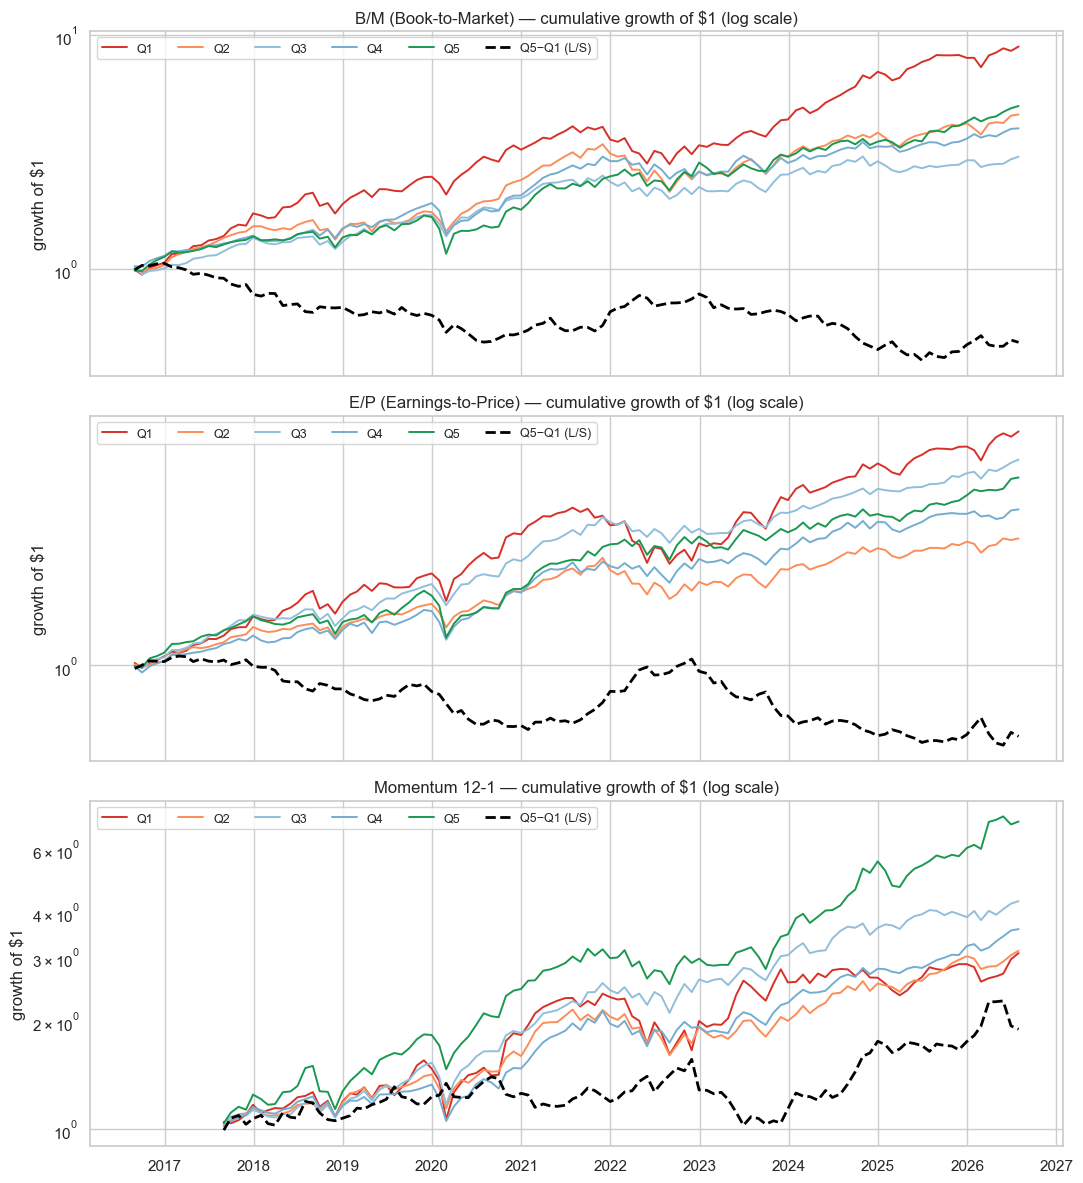

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)
colors = {"Q1": "#d73027", "Q2": "#fc8d59", "Q3": "#91bfdb",
          "Q4": "#74add1", "Q5": "#1a9850"}

for ax, (signal, r) in zip(axes, results.items()):
    pivot = r["pivot"]
    cum = (1 + pivot).cumprod()
    for q in pivot.columns:
        ax.plot(cum.index, cum[q], label=q, color=colors[q], lw=1.4)
    ls_cum = (1 + (pivot["Q5"] - pivot["Q1"])).cumprod()
    ax.plot(ls_cum.index, ls_cum, label="Q5−Q1 (L/S)", color="black", lw=2.0, ls="--")
    ax.set_yscale("log")
    ax.set_title(f"{FACTOR_LABELS[signal]} — cumulative growth of $1 (log scale)")
    ax.legend(ncol=6, fontsize=9)
    ax.set_ylabel("growth of $1")

axes[-1].set_xlabel("")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "notebooks" / "week2" / "quintile_cumulative_returns.png",
            dpi=130, bbox_inches="tight")
plt.show()

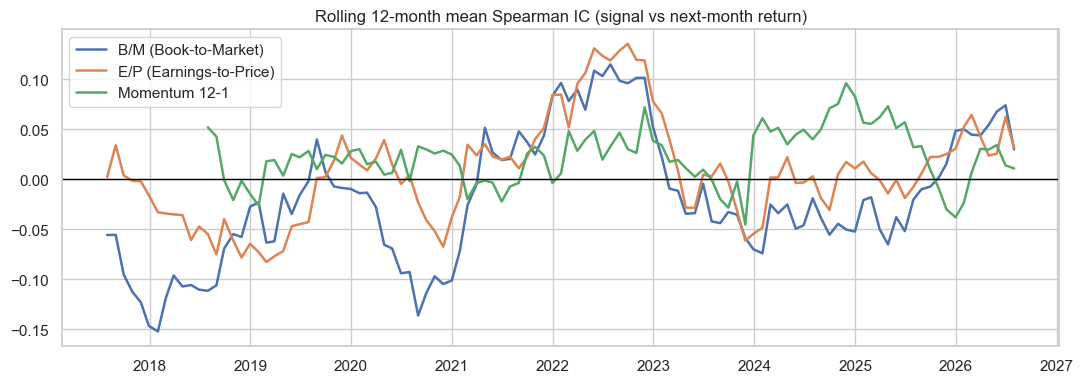

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
for signal, r in results.items():
    ic = r["ic"].set_index("date")["ic"]
    ax.plot(ic.index, ic.rolling(12).mean(), lw=1.8, label=FACTOR_LABELS[signal])
ax.axhline(0, color="black", lw=1)
ax.set_title("Rolling 12-month mean Spearman IC (signal vs next-month return)")
ax.legend()
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "notebooks" / "week2" / "rolling_ic.png", dpi=130, bbox_inches="tight")
plt.show()

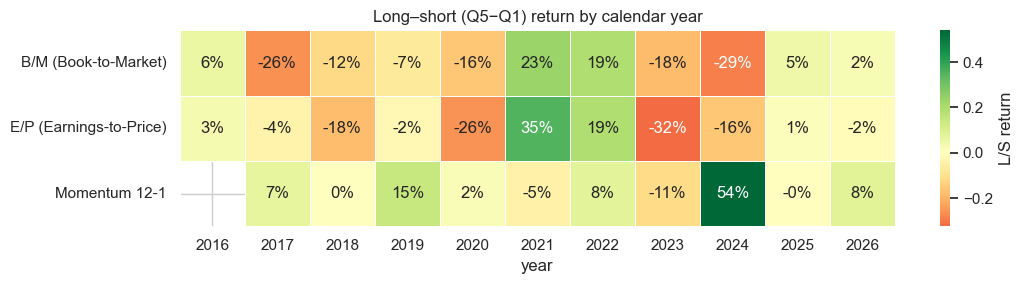

In [7]:
yearly = pd.DataFrame({FACTOR_LABELS[s]: yearly_ls_returns(r["ls"])
                       for s, r in results.items()})

fig, ax = plt.subplots(figsize=(11, 3))
sns.heatmap(yearly.T, annot=True, fmt=".0%", center=0, cmap="RdYlGn",
            linewidths=0.5, cbar_kws={"label": "L/S return"}, ax=ax)
ax.set_title("Long–short (Q5−Q1) return by calendar year")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "notebooks" / "week2" / "yearly_ls_heatmap.png",
            dpi=130, bbox_inches="tight")
plt.show()

## 4. Findings

1. **Momentum is the only factor with a positive premium in this universe.**
   Q5−Q1 earned **+8.8% annualized** (t = 1.43), mean IC +0.021, with Q5 (past winners)
   delivering 2.02% per month vs 1.29% for Q1 (past losers). The premium was strongest in
   trending markets (2019: +14.7%, 2024: +53.9% during the AI rally) and negative in sharp
   rotations (2021: −5.1% post-COVID style flip, 2023: −11.3%).
2. **Value had a negative premium over 2016–2026 — the "lost decade" for value.**
   B/M Q5−Q1 returned **−6.0% annualized** (t = −1.24, IC −0.018); E/P −5.0% (t = −0.98).
   Cheap (high B/M) stocks underperformed expensive growth stocks in growth-led years
   (2017: −26.3%, 2020: −16.1%, 2023–2024: −18.3% / −29.2%), while value came back strongly
   during the 2021–2022 rate-hike regime (**+23.4% / +19.2%**). E/P shows the same pattern,
   confirming the result is not an artifact of one value definition.
3. **Neither value signal is monotone across quintiles** — Q1 (growth) outperformed every
   other bucket, consistent with a mega-cap-tech-dominated decade in a large-cap universe.
4. **Statistical power caveat:** with ~120 monthly observations, t-stats around ±1–1.4 are
   economically meaningful but not statistically decisive; the *pattern across years* is the
   more robust evidence.

## 5. Limitations & Next Steps

**Limitations**

- **Survivorship bias:** the universe is today's S&P 500 constituents tracked over 10 years;
  delisted names are absent. Results overstate what a live portfolio would have earned.
- **Universe size:** 100 large caps → ~20 names per quintile; idiosyncratic risk is material.
- **Approximations:** weighted-average shares proxy period-end shares for multi-class firms
  (BRK-B patched from Yahoo share history); Yahoo "split" factors include spin-off price
  adjustments (market-cap-neutral by construction, noted for completeness); spin-off-year
  fundamentals (CARR 2020, AMCR 2019) have genuinely short histories.
- **Equal weighting** (per assignment); value-weighted results are computed but not shown.
- No transaction costs / turnover analysis.

**Next steps**

- Extend to 300–500 names to tighten standard errors; add sector-neutral quintile sorts.
- Combine signals (e.g., composite value + momentum) and test conditional performance
  (value in rising-rate regimes).
- Add turnover and transaction-cost modeling before any tradable conclusion.